In [559]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [560]:
# Project root
BASE_DIR = Path("..")

# Load processed datasets
fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

nav = pd.read_csv(
    BASE_DIR / "data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    BASE_DIR / "data/processed/07_scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    BASE_DIR / "data/processed/08_investor_transactions_clean.csv"
)

# Load other datasets
aum = pd.read_csv(
    BASE_DIR / "data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    BASE_DIR / "data/raw/04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    BASE_DIR / "data/raw/05_category_inflows.csv"
)

folio = pd.read_csv(
    BASE_DIR / "data/raw/06_industry_folio_count.csv"
)

holdings = pd.read_csv(
    BASE_DIR / "data/raw/09_portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    BASE_DIR / "data/raw/10_benchmark_indices.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [561]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "Performance": performance,
    "Transactions": transactions,
    "AUM": aum,
    "SIP": sip,
    "Category Inflows": category_inflows,
    "Folio": folio,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:20} : {df.shape}")

Fund Master          : (40, 15)
NAV History          : (46000, 3)
Performance          : (40, 19)
Transactions         : (32778, 13)
AUM                  : (90, 5)
SIP                  : (48, 6)
Category Inflows     : (144, 3)
Folio                : (21, 6)
Holdings             : (322, 8)
Benchmark            : (8050, 3)


In [562]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Date columns converted successfully.")

Date columns converted successfully.


In [563]:
print("Number of schemes:", fund_master["amfi_code"].nunique())
print("Number of fund houses:", fund_master["fund_house"].nunique())
print("Number of categories:", fund_master["category"].nunique())
print("NAV date range:", nav["date"].min(), "to", nav["date"].max())
print("SIP date range:", sip["month"].min(), "to", sip["month"].max())
print("Transaction date range:",
      transactions["transaction_date"].min(),
      "to",
      transactions["transaction_date"].max())

Number of schemes: 40
Number of fund houses: 10
Number of categories: 2
NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
SIP date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Transaction date range: 2024-01-01 00:00:00 to 2025-05-30 00:00:00


In [564]:
# Objective 1: NAV Trend Analysis

print("NAV date range:")
print(nav["date"].min(), "to", nav["date"].max())

print("\nNumber of schemes:")
print(nav["amfi_code"].nunique())

print("\nNAV rows:")
print(len(nav))

print("\nNAV observations per scheme:")
print(nav.groupby("amfi_code").size().describe())

NAV date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Number of schemes:
40

NAV rows:
46000

NAV observations per scheme:
count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64


In [565]:
# Add scheme names to NAV dataset

nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())
print("\nMissing scheme names:",
      nav_plot["scheme_name"].isna().sum())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth

Missing scheme names: 0


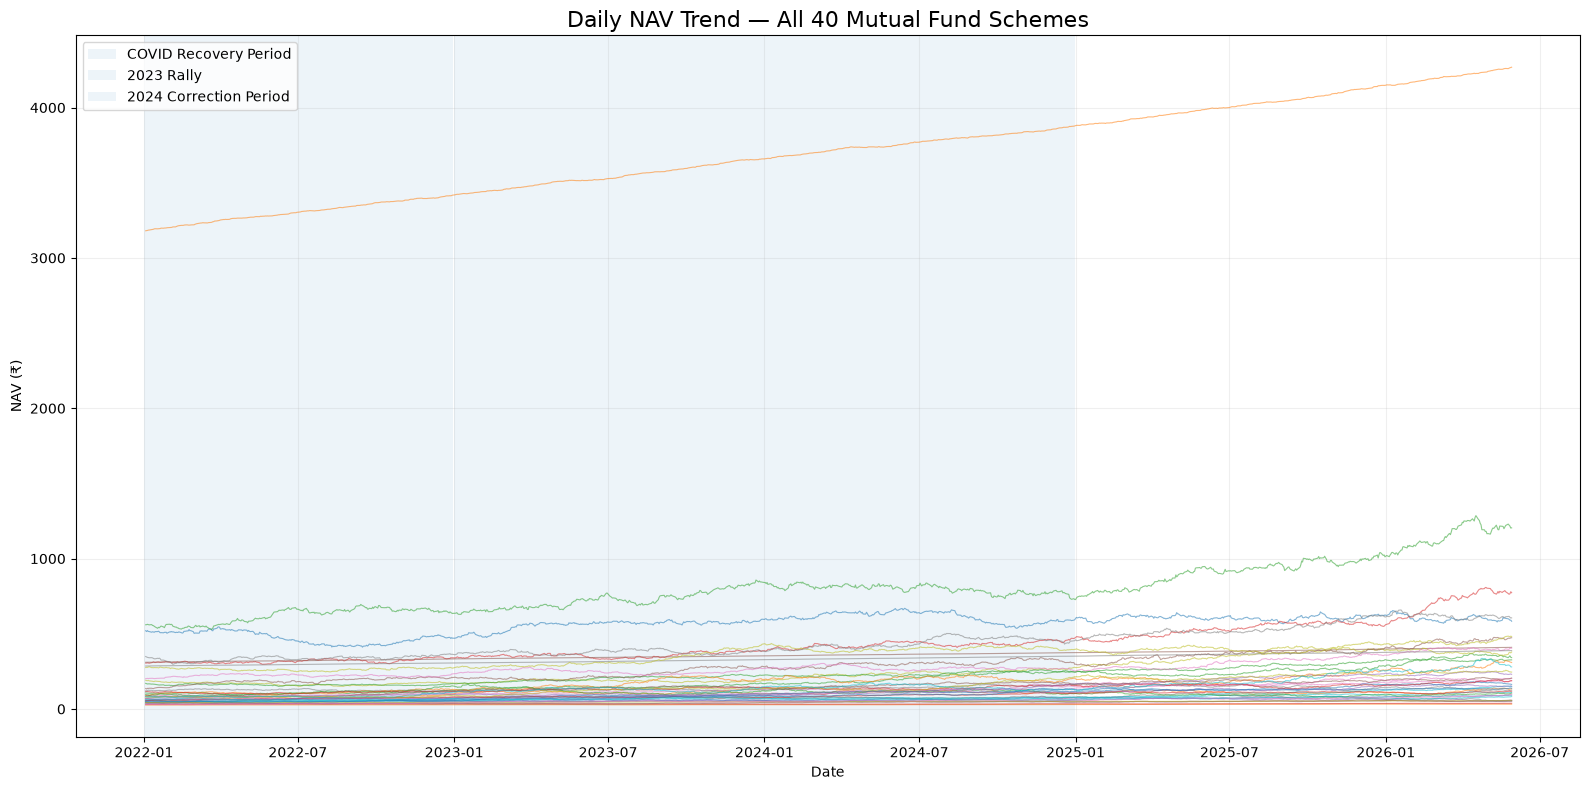

In [566]:
# Daily NAV trend for all 40 schemes

fig, ax = plt.subplots(figsize=(16, 8))

for scheme in nav_plot["scheme_name"].unique():
    scheme_data = nav_plot[
        nav_plot["scheme_name"] == scheme
    ].sort_values("date")

    ax.plot(
        scheme_data["date"],
        scheme_data["nav"],
        linewidth=0.8,
        alpha=0.55
    )

# Highlight requested periods
ax.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.08,
    label="COVID Recovery Period"
)

ax.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.08,
    label="2023 Rally"
)

ax.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.08,
    label="2024 Correction Period"
)

ax.set_title(
    "Daily NAV Trend — All 40 Mutual Fund Schemes",
    fontsize=16
)

ax.set_xlabel("Date")
ax.set_ylabel("NAV (₹)")

ax.legend(
    loc="upper left"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [567]:
# Normalize NAV for comparison

nav_normalized = nav_plot.sort_values(
    ["amfi_code", "date"]
).copy()

nav_normalized["nav_index"] = (
    nav_normalized["nav"] /
    nav_normalized.groupby("amfi_code")["nav"].transform("first")
) * 100

print(nav_normalized.head())

   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

    nav_index  
0  100.000000  
1   98.969432  
2  100.242689  
3   99.102180  
4   98.982267  


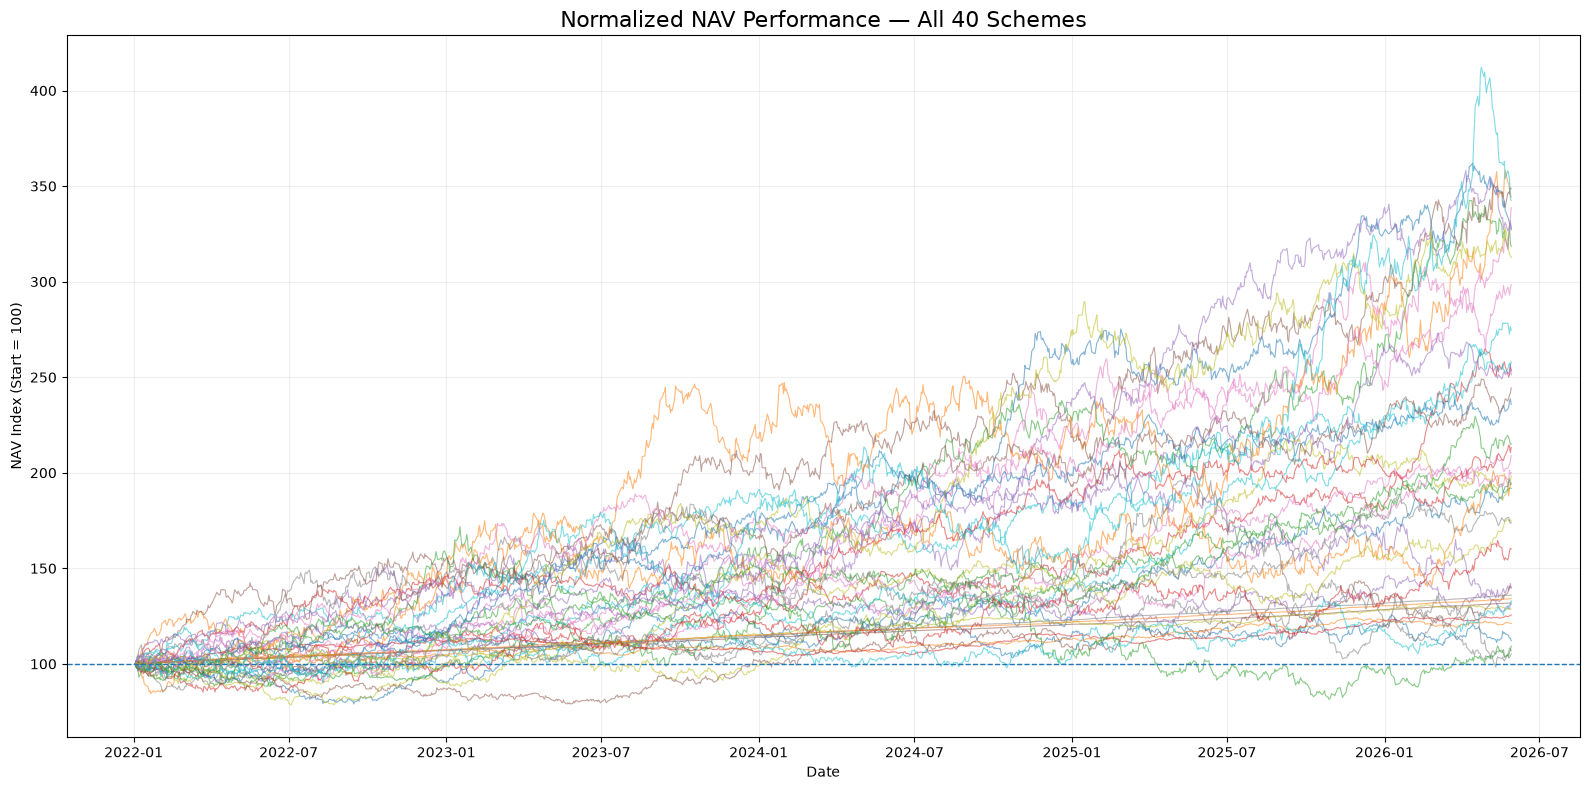

In [568]:
# Normalized NAV performance — all 40 schemes

fig, ax = plt.subplots(figsize=(16, 8))

for scheme in nav_normalized["scheme_name"].unique():
    scheme_data = nav_normalized[
        nav_normalized["scheme_name"] == scheme
    ]

    ax.plot(
        scheme_data["date"],
        scheme_data["nav_index"],
        linewidth=0.8,
        alpha=0.55
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Normalized NAV Performance — All 40 Schemes",
    fontsize=16
)

ax.set_xlabel("Date")
ax.set_ylabel("NAV Index (Start = 100)")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [569]:
# Year-wise average NAV

nav_yearly = (
    nav_plot
    .assign(year=nav_plot["date"].dt.year)
    .groupby("year")["nav"]
    .mean()
    .reset_index()
)

print("Year-wise Average NAV:")
print(nav_yearly)

Year-wise Average NAV:
   year         nav
0  2022  215.134633
1  2023  245.924607
2  2024  276.092448
3  2025  308.772270
4  2026  347.706715


In [570]:
# Objective 2: AUM Growth by Fund House

aum["year"] = aum["date"].dt.year

yearly_aum = (
    aum[
        aum["year"].between(2022, 2025)
    ]
    .groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

print("Yearly AUM:")
print(yearly_aum.head(20))

Yearly AUM:
    year                fund_house  aum_crore
0   2022  Aditya Birla Sun Life MF     563000
1   2022          Axis Mutual Fund     490000
2   2022           DSP Mutual Fund     222000
3   2022          HDFC Mutual Fund     880000
4   2022       ICICI Prudential MF     953000
5   2022         Kotak Mahindra MF     542000
6   2022            Mirae Asset MF     213000
7   2022           Nippon India MF     548000
8   2022           SBI Mutual Fund    1235000
9   2022           UTI Mutual Fund     462000
10  2023  Aditya Birla Sun Life MF     583000
11  2023          Axis Mutual Fund     501000
12  2023           DSP Mutual Fund     247000
13  2023          HDFC Mutual Fund     985000
14  2023       ICICI Prudential MF    1090000
15  2023         Kotak Mahindra MF     614000
16  2023            Mirae Asset MF     258000
17  2023           Nippon India MF     633000
18  2023           SBI Mutual Fund    1562000
19  2023           UTI Mutual Fund     504000


In [571]:
aum["year"] = aum["date"].dt.year

aum_year_end = (
    aum[aum["year"].between(2022, 2025)]
    .sort_values(["fund_house", "year", "date"])
    .groupby(["year", "fund_house"], as_index=False)
    .tail(1)
)

yearly_aum = (
    aum_year_end[["year", "fund_house", "aum_crore"]]
    .sort_values(["year", "fund_house"])
)

yearly_total_aum = (
    yearly_aum.groupby("year")["aum_crore"]
    .sum()
    .reset_index()
)

yearly_total_aum["aum_lakh_crore"] = (
    yearly_total_aum["aum_crore"] / 100000
)

yearly_total_aum

,year,aum_crore,aum_lakh_crore
0,2022,3090000,30.90
1,2023,3742000,37.42
2,2024,5268000,52.68
3,2025,6274000,62.74


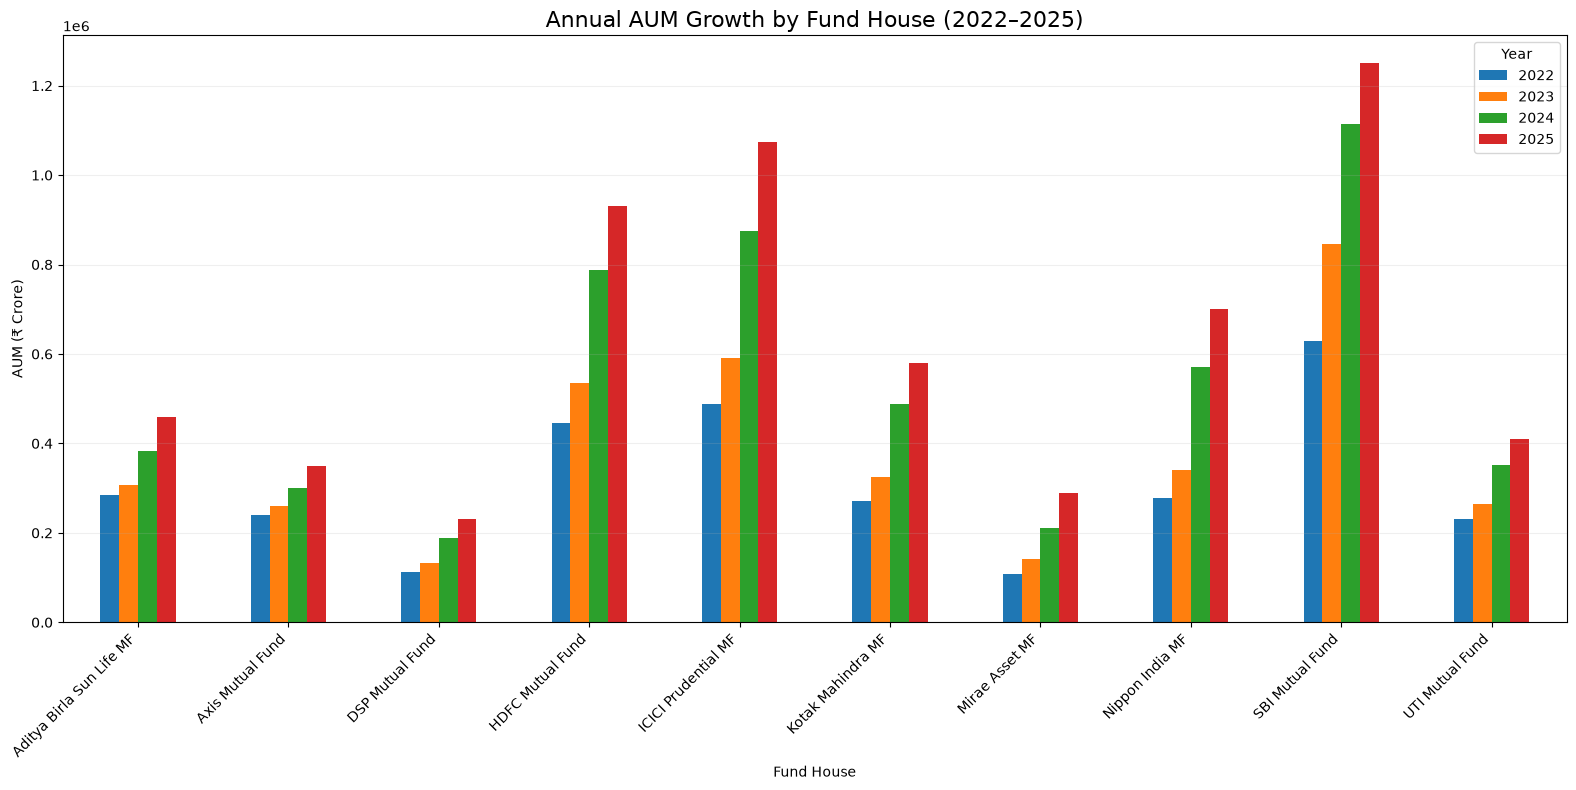

In [572]:
# Grouped bar chart: AUM by Fund House and Year

aum_pivot = yearly_aum.pivot(
    index="fund_house",
    columns="year",
    values="aum_crore"
)

ax = aum_pivot.plot(
    kind="bar",
    figsize=(16, 8)
)

ax.set_title(
    "Annual AUM Growth by Fund House (2022–2025)",
    fontsize=16
)

ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (₹ Crore)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [573]:
# Dominant fund house by year

dominant_by_year = (
    yearly_aum.loc[
        yearly_aum.groupby("year")["aum_crore"].idxmax()
    ]
    .sort_values("year")
)

print("Dominant Fund House by Year:")
print(
    dominant_by_year[
        ["year", "fund_house", "aum_crore"]
    ]
)

Dominant Fund House by Year:
    year       fund_house  aum_crore
10  2022  SBI Mutual Fund     630000
30  2023  SBI Mutual Fund     845000
60  2024  SBI Mutual Fund    1114000
80  2025  SBI Mutual Fund    1250000


In [574]:
sbi_aum = yearly_aum[
    yearly_aum["fund_house"].str.contains(
        "SBI",
        case=False,
        na=False
    )
].sort_values("year")

print("SBI AUM by Year:")
print(sbi_aum)

SBI AUM by Year:
    year       fund_house  aum_crore
10  2022  SBI Mutual Fund     630000
30  2023  SBI Mutual Fund     845000
60  2024  SBI Mutual Fund    1114000
80  2025  SBI Mutual Fund    1250000


In [575]:
sbi_share = sbi_aum.merge(
    yearly_total_aum,
    on="year",
    suffixes=("_sbi", "_total")
)

sbi_share["sbi_share_pct"] = (
    sbi_share["aum_crore_sbi"]
    / sbi_share["aum_crore_total"]
) * 100

print("SBI Share of Total AUM:")
print(
    sbi_share[
        ["year", "aum_crore_sbi", "aum_crore_total", "sbi_share_pct"]
    ]
)

SBI Share of Total AUM:
   year  aum_crore_sbi  aum_crore_total  sbi_share_pct
0  2022         630000          3090000      20.388350
1  2023         845000          3742000      22.581507
2  2024        1114000          5268000      21.146545
3  2025        1250000          6274000      19.923494


In [576]:
# Objective 3: SIP Inflow Trend

print("SIP date range:")
print(sip["month"].min(), "to", sip["month"].max())

print("\nNumber of months:", len(sip))

print("\nSIP columns:")
print(sip.columns.tolist())

SIP date range:
2022-01-01 00:00:00 to 2025-12-01 00:00:00

Number of months: 48

SIP columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


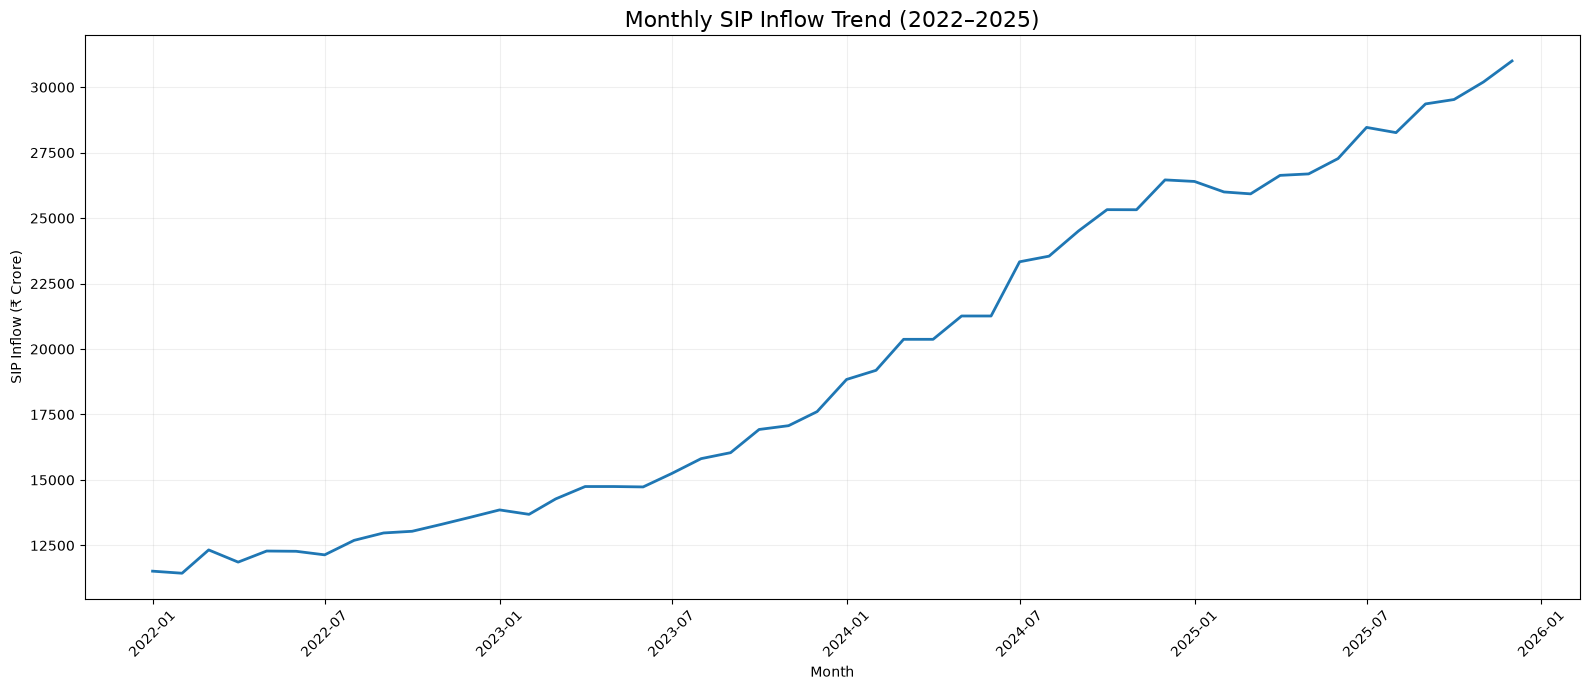

In [577]:
plt.figure(figsize=(16, 7))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    linewidth=2
)

plt.title(
    "Monthly SIP Inflow Trend (2022–2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [578]:
dec_2025 = sip[
    sip["month"] == pd.Timestamp("2025-12-01")
]

print("December 2025 SIP Inflow:")
print(dec_2025)

December 2025 SIP Inflow:
        month  sip_inflow_crore  active_sip_accounts_crore  \
47 2025-12-01             31002                       9.35   

    new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
47                    9.8                15.9           17.17  


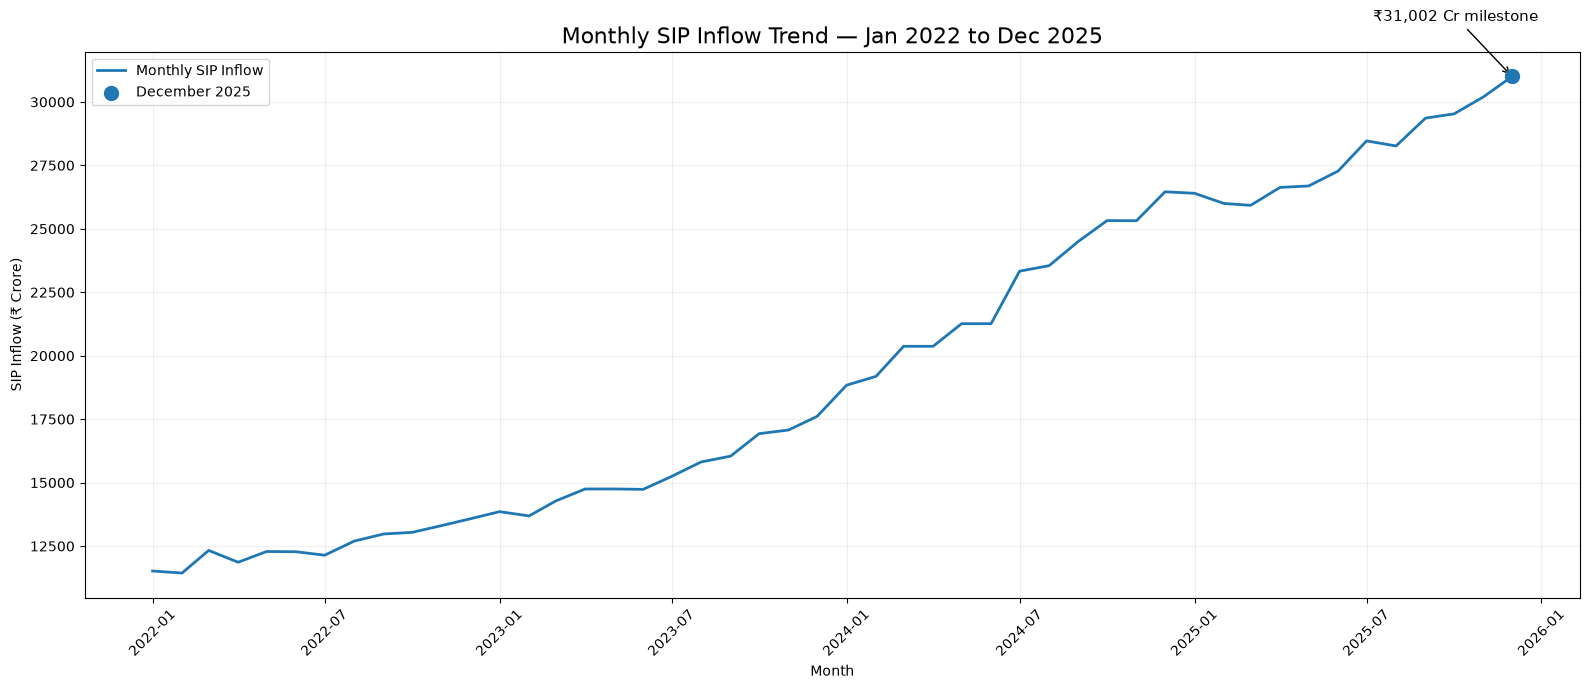

In [579]:
plt.figure(figsize=(16, 7))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    linewidth=2,
    label="Monthly SIP Inflow"
)

# December 2025 milestone
plt.scatter(
    dec_2025["month"],
    dec_2025["sip_inflow_crore"],
    s=100,
    zorder=5,
    label="December 2025"
)

plt.annotate(
    "₹31,002 Cr milestone",
    xy=(
        dec_2025["month"].iloc[0],
        dec_2025["sip_inflow_crore"].iloc[0]
    ),
    xytext=(-100, 40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.title(
    "Monthly SIP Inflow Trend — Jan 2022 to Dec 2025",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [580]:
sip["year"] = sip["month"].dt.year

yearly_sip = (
    sip.groupby("year")["sip_inflow_crore"]
    .agg(["sum", "mean", "min", "max"])
    .reset_index()
)

print("Year-wise SIP Inflow Summary:")
print(yearly_sip)

Year-wise SIP Inflow Summary:
   year     sum          mean    min    max
0  2022  149437  12453.083333  11438  13573
1  2023  184763  15396.916667  13687  17610
2  2024  269781  22481.750000  18838  26459
3  2025  335740  27978.333333  25926  31002


In [581]:
highest_sip = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print("Highest SIP Inflow Month:")
print(highest_sip)

Highest SIP Inflow Month:
month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
year                                        2025
Name: 47, dtype: object


In [582]:
# Objective 4: Category-wise Inflow Heatmap

category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# Create month labels
category_inflows["month_label"] = (
    category_inflows["month"].dt.strftime("%b-%Y")
)

# Pivot table for heatmap
inflow_heatmap = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print("Heatmap data shape:", inflow_heatmap.shape)
print(inflow_heatmap.head())

Heatmap data shape: (12, 12)
month            2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                      
ELSS                  466.0       553.0       472.0       471.0       499.0   
Flexi Cap            4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                  784.0       836.0       864.0       959.0       952.0   
Hybrid               2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap      4214.0      4368.0      4610.0      5023.0      5411.0   

month            2024-09-01  2024-10-01  2024-11-01  2024-12-01  2025-01-01  \
category                                                                      
ELSS                  537.0       537.0       571.0       521.0       516.0   
Flexi Cap            5397.0      6004.0      6111.0      4654.0      5603.0   
Gilt                  925.0       898.0       704.0       831.0       744.0   
Hybrid               3

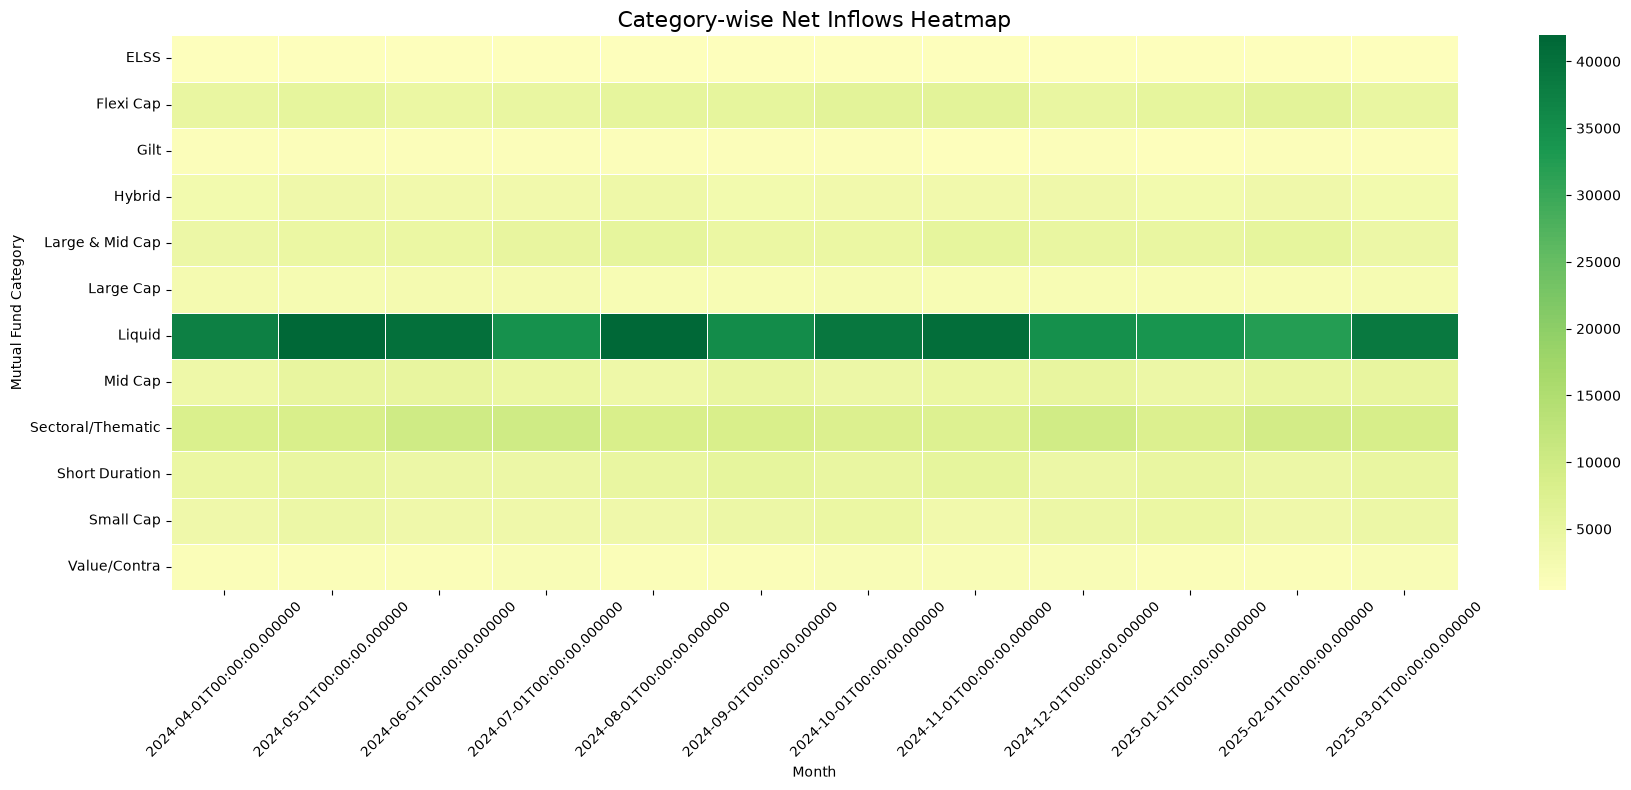

In [583]:
plt.figure(figsize=(18, 8))

sns.heatmap(
    inflow_heatmap,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflows Heatmap",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Mutual Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [584]:
category_summary = (
    category_inflows
    .groupby("category")["net_inflow_crore"]
    .agg(
        total_inflow="sum",
        average_monthly_inflow="mean",
        highest_monthly_inflow="max",
        lowest_monthly_inflow="min"
    )
    .sort_values("total_inflow", ascending=False)
)

print("Category-wise Inflow Summary:")
print(category_summary)

Category-wise Inflow Summary:
                   total_inflow  average_monthly_inflow  \
category                                                  
Liquid                 451275.0            37606.250000   
Sectoral/Thematic      103829.0             8652.416667   
Flexi Cap               63989.0             5332.416667   
Large & Mid Cap         57752.0             4812.666667   
Short Duration          55530.0             4627.500000   
Mid Cap                 55312.0             4609.333333   
Small Cap               46596.0             3883.000000   
Hybrid                  38868.0             3239.000000   
Large Cap               25633.0             2136.083333   
Value/Contra            16980.0             1415.000000   
Gilt                    10395.0              866.250000   
ELSS                     6080.0              506.666667   

                   highest_monthly_inflow  lowest_monthly_inflow  
category                                                          
Liquid   

In [585]:
max_category_flow = category_inflows.loc[
    category_inflows["net_inflow_crore"].idxmax()
]

min_category_flow = category_inflows.loc[
    category_inflows["net_inflow_crore"].idxmin()
]

print("Highest Category Inflow:")
print(max_category_flow[
    ["month", "category", "net_inflow_crore"]
])

print("\nLowest Category Inflow:")
print(min_category_flow[
    ["month", "category", "net_inflow_crore"]
])

Highest Category Inflow:
month               2024-08-01 00:00:00
category                         Liquid
net_inflow_crore                41952.0
Name: 56, dtype: object

Lowest Category Inflow:
month               2025-02-01 00:00:00
category                           ELSS
net_inflow_crore                  437.0
Name: 125, dtype: object


In [586]:
# Objective 5: Investor Demographics

print("Age Group Distribution:")
print(transactions["age_group"].value_counts())

print("\nAge Group Percentages:")
print(
    transactions["age_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Age Group Distribution:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Age Group Percentages:
age_group
26-35    41.07
36-45    24.85
18-25    15.00
46-55    11.53
56+       7.55
Name: proportion, dtype: float64


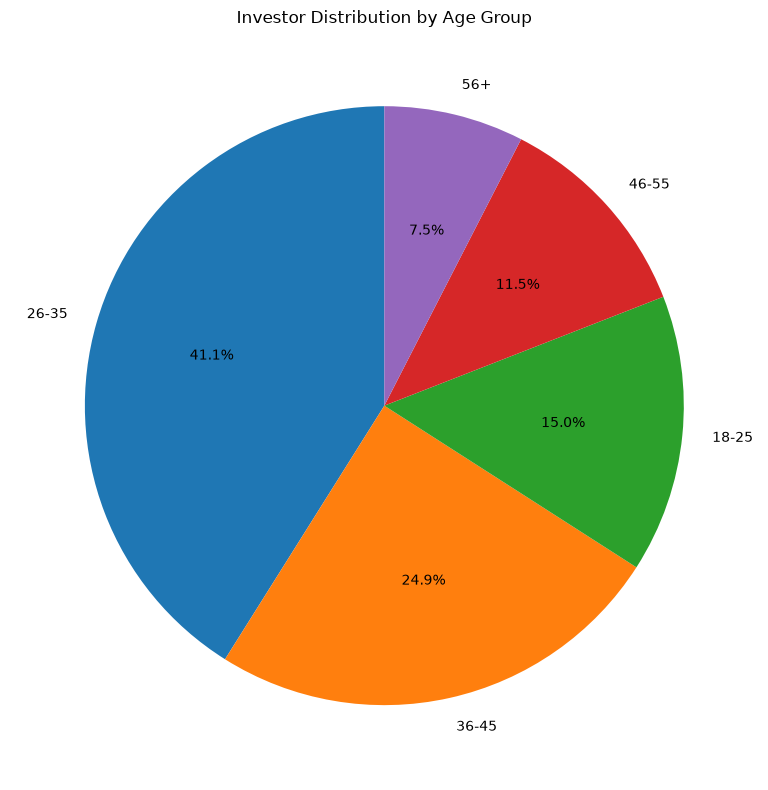

In [587]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.tight_layout()
plt.show()

In [588]:
sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

print("Total SIP transactions:", len(sip_transactions))

print("\nSIP amount summary:")
print(sip_transactions["amount_inr"].describe())

Total SIP transactions: 19716

SIP amount summary:
count    19716.000000
mean     11018.132025
std      14218.202038
min        400.000000
25%       2116.750000
50%       5139.000000
75%      13554.250000
max      59998.000000
Name: amount_inr, dtype: float64


In [589]:
sip_age_summary = (
    sip_transactions
    .groupby("age_group")["amount_inr"]
    .agg(
        count="count",
        total="sum",
        average="mean",
        median="median"
    )
    .sort_values("total", ascending=False)
)

print("SIP Amount Summary by Age Group:")
print(sip_age_summary)

SIP Amount Summary by Age Group:
           count     total       average  median
age_group                                       
26-35       8063  88587340  10986.895696  5070.0
36-45       4926  53623247  10885.758628  5250.0
18-25       2949  32300613  10953.073245  5020.0
46-55       2300  25614556  11136.763478  5136.0
56+         1478  17107735  11574.922192  5420.5


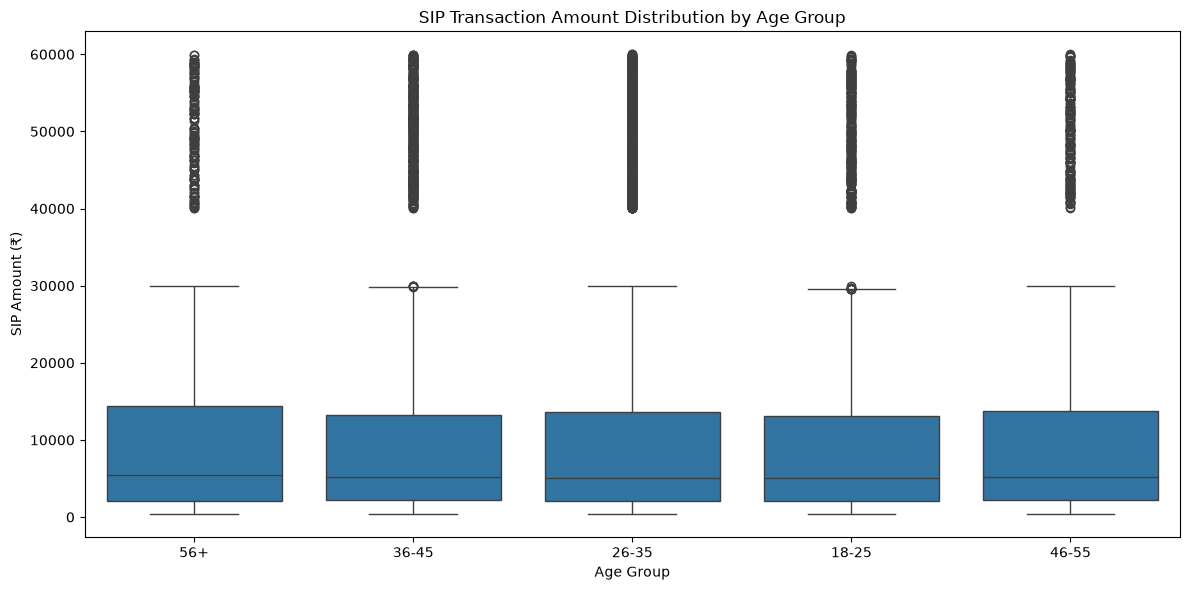

In [590]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Transaction Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

In [591]:
print("SIP Amount Percentiles:")

print(
    sip_transactions["amount_inr"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

SIP Amount Percentiles:
0.25     2116.75
0.50     5139.00
0.75    13554.25
0.90    28817.50
0.95    48686.75
0.99    57538.10
Name: amount_inr, dtype: float64


In [592]:
# Objective 6: Geographic Distribution

state_sip = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Total SIP Amount by State:")
print(state_sip)

Total SIP Amount by State:
state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Rajasthan         16544233
Maharashtra       16445629
Name: amount_inr, dtype: int64


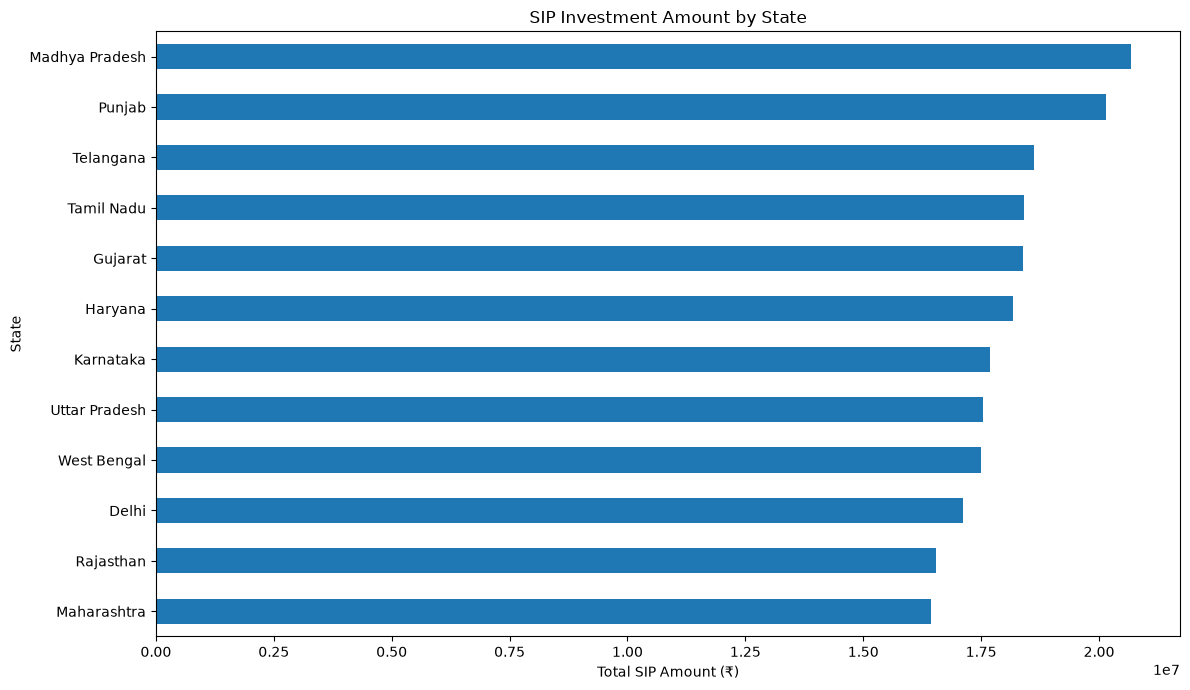

In [593]:
plt.figure(figsize=(12, 7))

state_sip.sort_values().plot(kind="barh")

plt.title("SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [594]:
print("City Tier Distribution:")
print(
    sip_transactions["city_tier"]
    .value_counts()
)

City Tier Distribution:
city_tier
T30    13123
B30     6593
Name: count, dtype: int64


In [595]:
tier_sip = (
    sip_transactions
    .groupby("city_tier")["amount_inr"]
    .agg(
        total_sip="sum",
        average_sip="mean",
        median_sip="median",
        transactions="count"
    )
)

print("T30 vs B30 SIP Analysis:")
print(tier_sip)

T30 vs B30 SIP Analysis:
           total_sip   average_sip  median_sip  transactions
city_tier                                                   
B30         72304870  10966.914910      5264.0          6593
T30        144928621  11043.863522      5071.0         13123


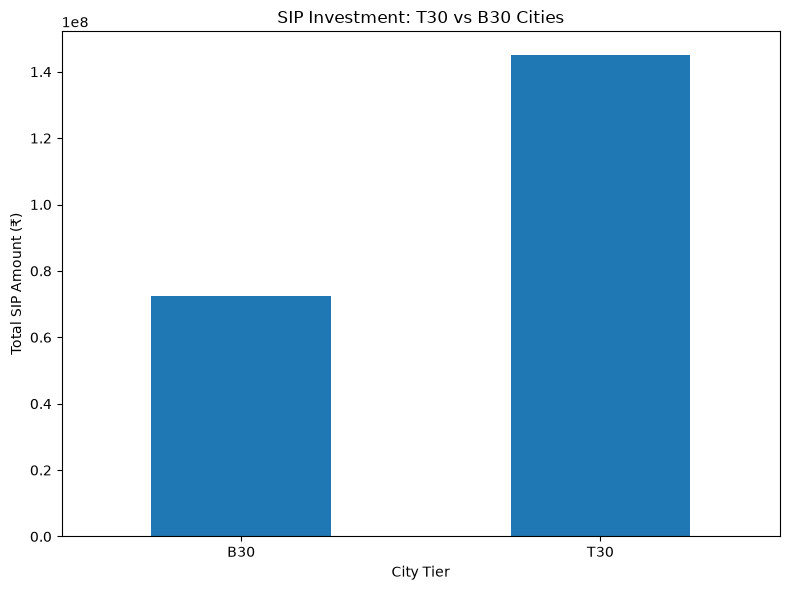

In [596]:
plt.figure(figsize=(8, 6))

tier_sip["total_sip"].plot(
    kind="bar"
)

plt.title("SIP Investment: T30 vs B30 Cities")
plt.xlabel("City Tier")
plt.ylabel("Total SIP Amount (₹)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [597]:
tier_sip["share_pct"] = (
    tier_sip["total_sip"]
    / tier_sip["total_sip"].sum()
) * 100

print("T30 vs B30 SIP Share:")
print(
    tier_sip[
        ["total_sip", "share_pct"]
    ]
)

T30 vs B30 SIP Share:
           total_sip  share_pct
city_tier                      
B30         72304870  33.284403
T30        144928621  66.715597


In [598]:
# Objective 7: Folio Count Growth

folio["month"] = pd.to_datetime(folio["month"])

print("Folio date range:")
print(folio["month"].min(), "to", folio["month"].max())

print("\nFirst folio observation:")
print(folio.iloc[0])

print("\nLast folio observation:")
print(folio.iloc[-1])

Folio date range:
2022-01-01 00:00:00 to 2025-12-01 00:00:00

First folio observation:
month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object

Last folio observation:
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


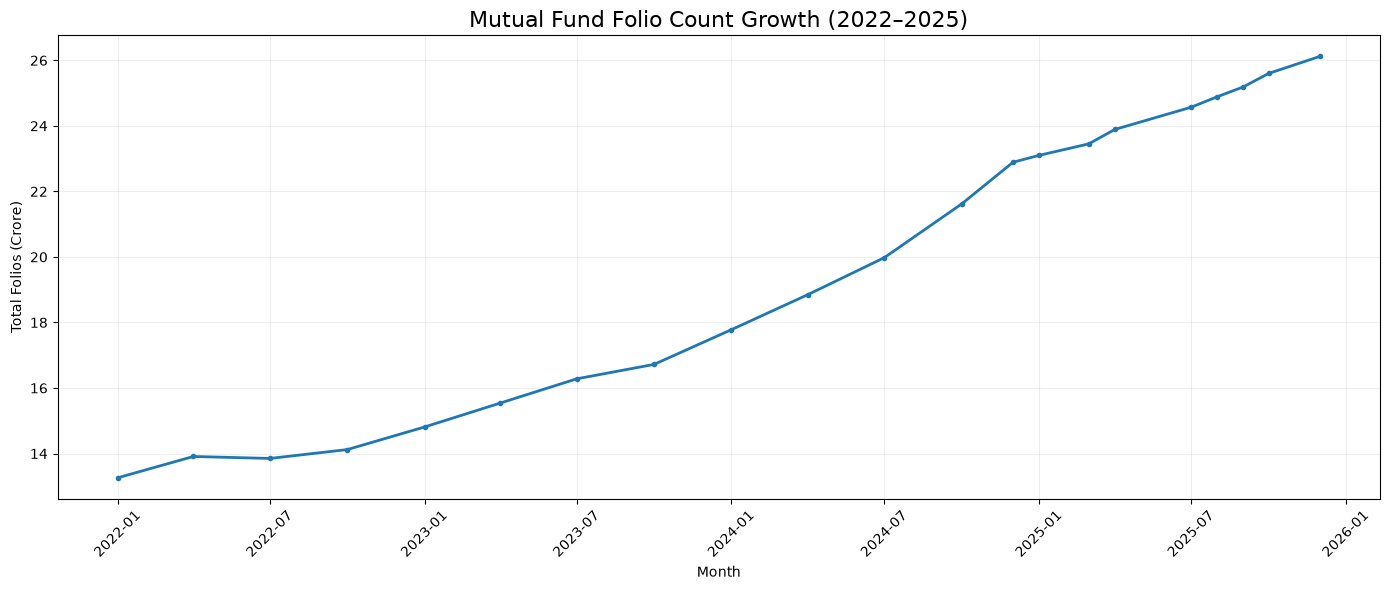

In [599]:
plt.figure(figsize=(14, 6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2,
    marker="o",
    markersize=3
)

plt.title(
    "Mutual Fund Folio Count Growth (2022–2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

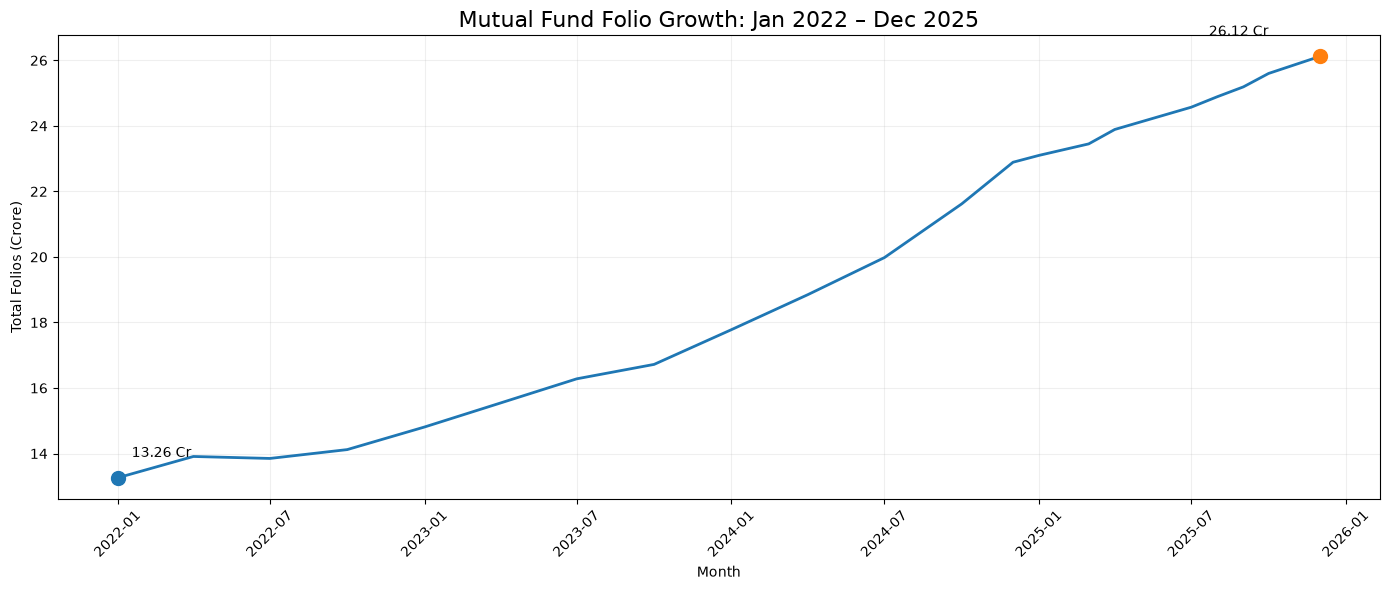

In [600]:
first_row = folio.iloc[0]
last_row = folio.iloc[-1]

plt.figure(figsize=(14, 6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

# Starting point
plt.scatter(
    first_row["month"],
    first_row["total_folios_crore"],
    s=100,
    zorder=5
)

plt.annotate(
    f'{first_row["total_folios_crore"]:.2f} Cr',
    xy=(
        first_row["month"],
        first_row["total_folios_crore"]
    ),
    xytext=(10, 15),
    textcoords="offset points"
)

# Ending point
plt.scatter(
    last_row["month"],
    last_row["total_folios_crore"],
    s=100,
    zorder=5
)

plt.annotate(
    f'{last_row["total_folios_crore"]:.2f} Cr',
    xy=(
        last_row["month"],
        last_row["total_folios_crore"]
    ),
    xytext=(-80, 15),
    textcoords="offset points"
)

plt.title(
    "Mutual Fund Folio Growth: Jan 2022 – Dec 2025",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [601]:
initial_folios = first_row["total_folios_crore"]
final_folios = last_row["total_folios_crore"]

absolute_growth = final_folios - initial_folios

percentage_growth = (
    absolute_growth / initial_folios
) * 100

print(f"Initial folios : {initial_folios:.2f} Cr")
print(f"Final folios   : {final_folios:.2f} Cr")
print(f"Absolute growth: {absolute_growth:.2f} Cr")
print(f"Percentage growth: {percentage_growth:.2f}%")

Initial folios : 13.26 Cr
Final folios   : 26.12 Cr
Absolute growth: 12.86 Cr
Percentage growth: 96.98%


In [602]:
# ============================================================
# OBJECTIVE 8: CORRELATION MATRIX OF NAV RETURNS
# ============================================================

# Select 10 funds
selected_codes = (
    fund_master["amfi_code"]
    .sort_values()
    .head(10)
    .tolist()
)

selected_funds = fund_master[
    fund_master["amfi_code"].isin(selected_codes)
][["amfi_code", "scheme_name"]]

display(selected_funds)

,amfi_code,scheme_name
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,100025,HDFC Short Term Debt Fund - Regular - Growth
15,118632,Nippon India Large Cap Fund - Regular - Growth
28,101206,ABSL Frontline Equity Fund - Regular - Growth
29,101207,ABSL Small Cap Fund - Regular - Growth
30,101208,ABSL Liquid Fund - Regular - Growth
31,102885,UTI Nifty 50 Index Fund - Regular - Growth
32,102886,UTI Mid Cap Fund - Regular - Growth
33,102887,UTI Flexi Cap Fund - Regular - Growth


In [603]:
nav_selected = nav[
    nav["amfi_code"].isin(selected_codes)
].copy()

nav_selected = nav_selected.merge(
    selected_funds,
    on="amfi_code",
    how="left"
)

nav_selected = nav_selected.sort_values(
    ["scheme_name", "date"]
)

display(nav_selected.head())

,amfi_code,date,nav,scheme_name
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [604]:
nav_selected["daily_return"] = (
    nav_selected
    .groupby("scheme_name")["nav"]
    .pct_change()
)

In [605]:
return_summary = (
    nav_selected
    .groupby("scheme_name")["daily_return"]
    .agg(["count", "mean", "std", "min", "max"])
)

display(return_summary)

,count,mean,std,min,max
scheme_name,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1149,0.000852,0.009177,-0.038121,0.033956
ABSL Liquid Fund - Regular - Growth,1149,0.000242,0.000319,-0.000766,0.001247
ABSL Small Cap Fund - Regular - Growth,1149,0.000424,0.016251,-0.051847,0.054851
HDFC Mid-Cap Opportunities Fund - Regular - Growth,1149,0.001080,0.011929,-0.044238,0.041954
HDFC Short Term Debt Fund - Regular - Growth,1149,0.000170,0.002460,-0.008188,0.008837
HDFC Top 100 Fund - Regular Plan - Growth,1149,0.000142,0.009164,-0.024744,0.032145
Nippon India Large Cap Fund - Regular - Growth,1149,0.000865,0.008913,-0.028490,0.028218
UTI Flexi Cap Fund - Regular - Growth,1149,0.000645,0.009927,-0.031271,0.032386
UTI Mid Cap Fund - Regular - Growth,1149,0.000110,0.011424,-0.036695,0.040745


In [606]:
return_matrix = nav_selected.pivot(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

display(return_matrix.head())

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369


In [607]:
# Objective 9: Top Holdings Sector Distribution

print("Holdings shape:", holdings.shape)

print("\nColumns:")
print(holdings.columns.tolist())

print("\nSectors:")
print(holdings["sector"].value_counts())

Holdings shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Sectors:
sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64


In [608]:
corr_matrix = return_matrix.corr(
    method="pearson",
    min_periods=30
)

display(corr_matrix.round(3))

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000,-0.027,0.010,-0.018,0.024,0.028,-0.005,-0.006,0.007,0.002
ABSL Liquid Fund - Regular - Growth,-0.027,1.000,-0.008,0.008,0.018,-0.034,0.004,0.037,0.014,-0.001
ABSL Small Cap Fund - Regular - Growth,0.010,-0.008,1.000,0.000,-0.007,0.016,0.043,0.002,0.005,-0.006
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018,0.008,0.000,1.000,0.002,-0.000,-0.013,-0.037,-0.018,-0.034
HDFC Short Term Debt Fund - Regular - Growth,0.024,0.018,-0.007,0.002,1.000,0.046,-0.014,-0.006,0.014,-0.001
HDFC Top 100 Fund - Regular Plan - Growth,0.028,-0.034,0.016,-0.000,0.046,1.000,-0.027,-0.023,-0.006,-0.094
Nippon India Large Cap Fund - Regular - Growth,-0.005,0.004,0.043,-0.013,-0.014,-0.027,1.000,0.001,-0.040,-0.000
UTI Flexi Cap Fund - Regular - Growth,-0.006,0.037,0.002,-0.037,-0.006,-0.023,0.001,1.000,-0.008,-0.037
UTI Mid Cap Fund - Regular - Growth,0.007,0.014,0.005,-0.018,0.014,-0.006,-0.040,-0.008,1.000,0.021


In [609]:
sector_summary = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Portfolio Weight by Sector:")
print(sector_summary)

Total Portfolio Weight by Sector:
sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


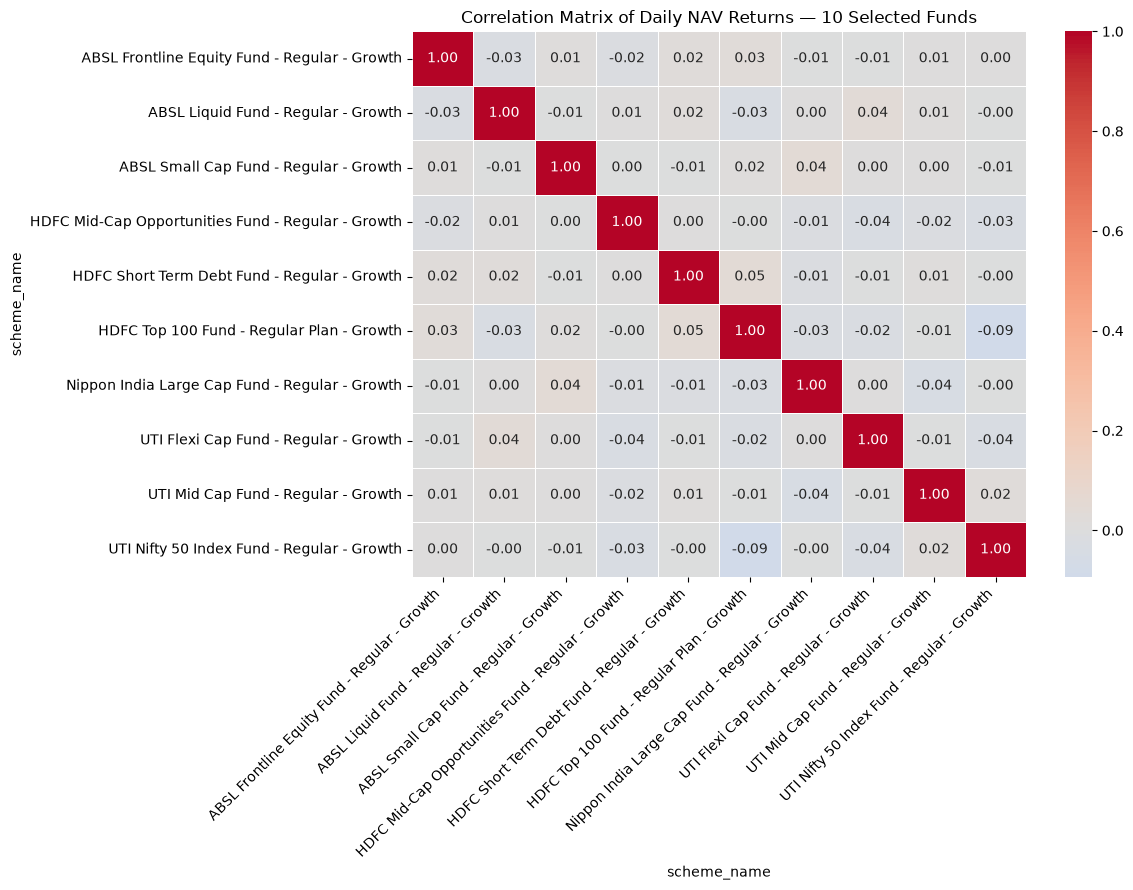

In [610]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns — 10 Selected Funds")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [611]:
# Remove diagonal, NaN values, and keep only unique pairs

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .dropna()
    .sort_values(ascending=False)
)

print("Number of valid unique fund pairs:", len(corr_pairs))

print("\nHighest correlation pairs:")
display(corr_pairs.head(5))

print("\nLowest correlation pairs:")
display(corr_pairs.tail(5))

Number of valid unique fund pairs: 45

Highest correlation pairs:


scheme_name                                    scheme_name                                   
HDFC Short Term Debt Fund - Regular - Growth   HDFC Top 100 Fund - Regular Plan - Growth         0.045567
ABSL Small Cap Fund - Regular - Growth         Nippon India Large Cap Fund - Regular - Growth    0.043384
ABSL Liquid Fund - Regular - Growth            UTI Flexi Cap Fund - Regular - Growth             0.036547
ABSL Frontline Equity Fund - Regular - Growth  HDFC Top 100 Fund - Regular Plan - Growth         0.027747
                                               HDFC Short Term Debt Fund - Regular - Growth      0.023769
dtype: float64


Lowest correlation pairs:


scheme_name                                         scheme_name                               
HDFC Mid-Cap Opportunities Fund - Regular - Growth  UTI Nifty 50 Index Fund - Regular - Growth   -0.034228
                                                    UTI Flexi Cap Fund - Regular - Growth        -0.036647
UTI Flexi Cap Fund - Regular - Growth               UTI Nifty 50 Index Fund - Regular - Growth   -0.036704
Nippon India Large Cap Fund - Regular - Growth      UTI Mid Cap Fund - Regular - Growth          -0.039886
HDFC Top 100 Fund - Regular Plan - Growth           UTI Nifty 50 Index Fund - Regular - Growth   -0.093533
dtype: float64

In [612]:
average_correlation = corr_pairs.mean()

print(
    f"Average pairwise correlation: "
    f"{average_correlation:.3f}"
)

Average pairwise correlation: -0.004


In [613]:
# ============================================================
# OBJECTIVE 9: TOP HOLDINGS SECTOR DISTRIBUTION
# ============================================================

print("Holdings Dataset Shape:", holdings.shape)

print("\nColumns:")
print(holdings.columns.tolist())

print("\nUnique sectors:")
print(holdings["sector"].nunique())

display(holdings.head())

Holdings Dataset Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Unique sectors:
14


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [614]:
sector_distribution = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print("Sector-wise Portfolio Weight:")
display(sector_distribution)

Sector-wise Portfolio Weight:


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [615]:
sector_summary = sector_distribution.reset_index()

sector_summary.columns = [
    "sector",
    "total_weight_pct"
]

sector_summary["share_of_total_pct"] = (
    sector_summary["total_weight_pct"]
    / sector_summary["total_weight_pct"].sum()
    * 100
)

display(sector_summary)

,sector,total_weight_pct,share_of_total_pct
0,Banking,652.26,19.184174
1,IT,455.47,13.396216
2,Pharma,407.45,11.983859
3,Automobile,323.65,9.519146
4,Utilities,265.54,7.810023
5,FMCG,229.11,6.738549
6,Infrastructure,192.16,5.651781
7,Diversified,169.23,4.977368
8,Telecom,145.62,4.282954
9,Consumer Goods,127.61,3.753246


In [616]:
top_5_sectors = sector_summary.head(5)

print("Top 5 Sectors:")
display(top_5_sectors)

Top 5 Sectors:


,sector,total_weight_pct,share_of_total_pct
0,Banking,652.26,19.184174
1,IT,455.47,13.396216
2,Pharma,407.45,11.983859
3,Automobile,323.65,9.519146
4,Utilities,265.54,7.810023


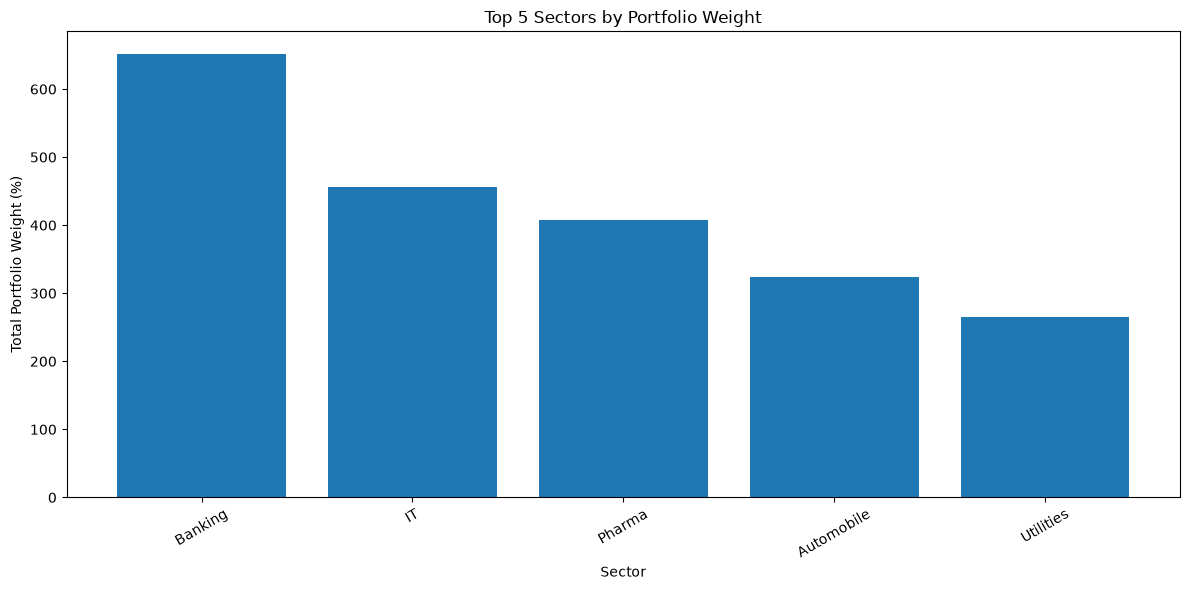

In [617]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_5_sectors["sector"],
    top_5_sectors["total_weight_pct"]
)

plt.title("Top 5 Sectors by Portfolio Weight")
plt.xlabel("Sector")
plt.ylabel("Total Portfolio Weight (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

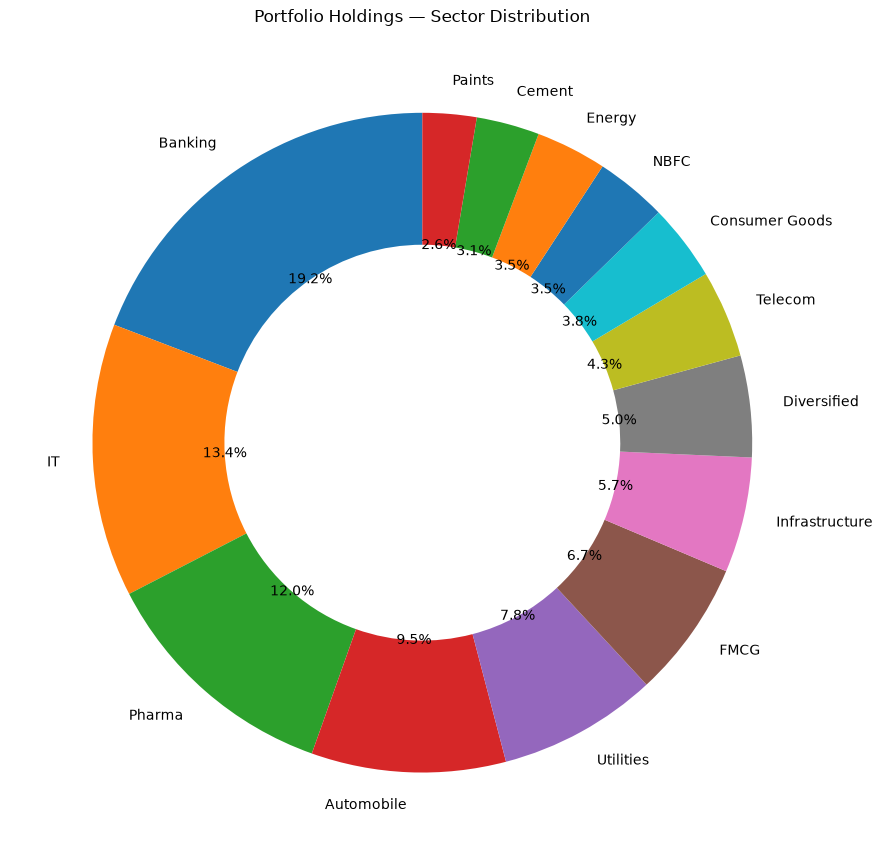

In [618]:
plt.figure(figsize=(9, 9))

plt.pie(
    sector_summary["total_weight_pct"],
    labels=sector_summary["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Portfolio Holdings — Sector Distribution")

plt.tight_layout()
plt.show()

In [619]:
# Objective 10: Generate Key EDA Metrics

print("=" * 60)
print("KEY EDA METRICS")
print("=" * 60)

# 1. Fund universe
print("\n1. FUND UNIVERSE")
print("Total schemes:", fund_master["amfi_code"].nunique())
print("Total fund houses:", fund_master["fund_house"].nunique())

# 2. NAV
print("\n2. NAV")
print("NAV date range:", nav["date"].min().date(), "to", nav["date"].max().date())
print("Number of schemes:", nav["amfi_code"].nunique())

# 3. AUM
print("\n3. AUM")
print(yearly_total_aum)

# 4. SIP
print("\n4. SIP")
print(
    sip.loc[
        sip["sip_inflow_crore"].idxmax(),
        ["month", "sip_inflow_crore"]
    ]
)

# 5. Category inflows
print("\n5. CATEGORY INFLOWS")
print(category_summary.head(5))

# 6. Age demographics
print("\n6. AGE GROUP")
print(
    transactions["age_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# 7. Geographic distribution
print("\n7. TOP STATES BY SIP AMOUNT")
print(state_sip.head(5))

print("\nT30 vs B30:")
print(tier_sip[["total_sip", "share_pct"]])

# 8. Folios
print("\n8. FOLIOS")
print(f"Initial: {initial_folios:.2f} Cr")
print(f"Final: {final_folios:.2f} Cr")
print(f"Growth: {percentage_growth:.2f}%")

# 9. Correlation
print("\n9. CORRELATION")
print("Highest correlation pairs:")
print(corr_pairs.head(3))

print("\nLowest correlation pairs:")
print(corr_pairs.tail(3))

# 10. Sector
print("\n10. TOP SECTORS")
print(top_5_sectors)
print(f"Top 5 sector concentration: {top_5_share:.2f}%")

KEY EDA METRICS

1. FUND UNIVERSE
Total schemes: 40
Total fund houses: 10

2. NAV
NAV date range: 2022-01-03 to 2026-05-29
Number of schemes: 40

3. AUM
   year  aum_crore  aum_lakh_crore
0  2022    3090000           30.90
1  2023    3742000           37.42
2  2024    5268000           52.68
3  2025    6274000           62.74

4. SIP
month               2025-12-01 00:00:00
sip_inflow_crore                  31002
Name: 47, dtype: object

5. CATEGORY INFLOWS
                   total_inflow  average_monthly_inflow  \
category                                                  
Liquid                 451275.0            37606.250000   
Sectoral/Thematic      103829.0             8652.416667   
Flexi Cap               63989.0             5332.416667   
Large & Mid Cap         57752.0             4812.666667   
Short Duration          55530.0             4627.500000   

                   highest_monthly_inflow  lowest_monthly_inflow  
category                                                  

# 10 Key EDA Findings

1. **Fund Universe:**  
   The dataset contains **40 mutual fund schemes** across **10 fund houses**, providing coverage across multiple fund categories and risk profiles.

2. **NAV Coverage:**  
   Historical NAV data covers all 40 schemes from **January 2022 to May 2026**, enabling analysis of long-term NAV trends and fund performance.

3. **AUM Growth:**  
   Fund-house AUM increased consistently from **₹30.90 lakh crore in 2022** to **₹62.74 lakh crore in 2025**, indicating strong growth in assets managed by the selected fund houses.

4. **SIP Inflows:**  
   Monthly SIP inflows reached **₹31,002 crore in December 2025**, representing the highest highlighted SIP inflow in the dataset.

5. **Category-wise Inflows:**  
   **Liquid funds** recorded the highest cumulative inflow at **₹4,51,275 crore**, followed by Sectoral/Thematic and Flexi Cap categories.

6. **Investor Age Distribution:**  
   Investors aged **26–35 years** form the largest age group, accounting for **41.07%** of the investor records, followed by the 36–45 age group at 24.85%.

7. **Geographic Distribution:**  
   **T30 cities contributed 66.72%** of total SIP amount, while B30 cities contributed 33.28%. Madhya Pradesh recorded the highest SIP amount among the states in the dataset.

8. **Folio Growth:**  
   Total mutual fund folios increased from **13.26 crore to 26.12 crore**, representing approximately **96.98% growth** over the observed period.

9. **Fund Return Correlation:**  
   The selected 10 funds show generally low pairwise correlations. The highest observed correlation was **0.046**, while the lowest valid pairwise correlation was approximately **-0.094**, indicating limited linear relationship among the selected fund returns.

10. **Sector Concentration:**  
    **Banking** is the largest sector by portfolio weight at **19.18%**, followed by IT (13.40%) and Pharma (11.98%). The top five sectors together account for **61.89%** of the total sector weight.
    